First install dependencies --->
pip install torch torchvision matplotlib
(Suggestion to use google Colab as we dont need to install anything and just select runtime as GPU)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale between -1 and 1
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# Use FashionMNIST by changing datasets.MNIST to datasets.FashionMNIST

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]


In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()  # for -1 to 1 scaling
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

for epoch in range(50):
    for real_imgs, _ in dataloader:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # Labels
        real = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, 100).to(device)
        gen_imgs = generator(z)
        real_loss = criterion(discriminator(real_imgs), real)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake)
        d_loss = real_loss + fake_loss
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        z = torch.randn(batch_size, 100).to(device)
        gen_imgs = generator(z)
        g_loss = criterion(discriminator(gen_imgs), real)  # Generator tries to fool the discriminator
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1} / 50, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")


Epoch 1 / 50, D Loss: 0.7939, G Loss: 1.7337
Epoch 2 / 50, D Loss: 1.2169, G Loss: 2.6975
Epoch 3 / 50, D Loss: 0.4985, G Loss: 2.5465
Epoch 4 / 50, D Loss: 1.1977, G Loss: 1.5460
Epoch 5 / 50, D Loss: 1.6456, G Loss: 1.9840
Epoch 6 / 50, D Loss: 0.6482, G Loss: 1.8174
Epoch 7 / 50, D Loss: 1.0979, G Loss: 3.5758
Epoch 8 / 50, D Loss: 0.5168, G Loss: 2.1072
Epoch 9 / 50, D Loss: 1.3384, G Loss: 2.5126
Epoch 10 / 50, D Loss: 0.5680, G Loss: 2.6990
Epoch 11 / 50, D Loss: 0.7660, G Loss: 1.8590
Epoch 12 / 50, D Loss: 1.3321, G Loss: 2.7689
Epoch 13 / 50, D Loss: 0.6033, G Loss: 2.1152
Epoch 14 / 50, D Loss: 1.0169, G Loss: 2.1657
Epoch 15 / 50, D Loss: 1.0003, G Loss: 3.6475
Epoch 16 / 50, D Loss: 0.4781, G Loss: 2.8961
Epoch 17 / 50, D Loss: 0.4592, G Loss: 2.8489
Epoch 18 / 50, D Loss: 0.4140, G Loss: 3.1466
Epoch 19 / 50, D Loss: 0.6419, G Loss: 5.1942
Epoch 20 / 50, D Loss: 0.5320, G Loss: 2.2678
Epoch 21 / 50, D Loss: 0.4875, G Loss: 3.1464
Epoch 22 / 50, D Loss: 0.5621, G Loss: 3.10

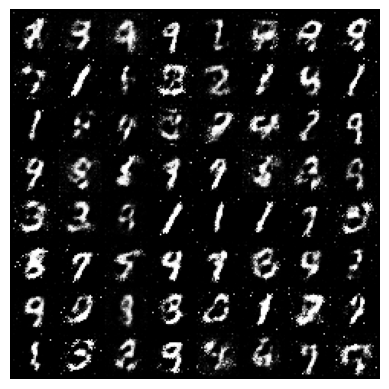

In [5]:
import torchvision.utils as vutils

with torch.no_grad():
    z = torch.randn(64, 100).to(device)
    gen_imgs = generator(z)
    grid = vutils.make_grid(gen_imgs, normalize=True)
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()
